<a href="https://colab.research.google.com/github/2412tessa-gif/UM-MSP-BIGDATAINPHYSICS/blob/main/PRA3024_2026_Cosmology_finalversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style='color:deepskyblue'> Cosmology MCMC notebook </span>

## <span style='color:deepskyblue'>Preliminaries</span>

In [1]:
# Install required packages (if not available on server, uncomment the lines below)

!pip3 install --upgrade pip
!pip3 install getdist
!pip3 install numpy
!pip3 install scipy
!pip3 install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 834.0/834.0 kB 9.6 MB/s  0:00:00


In [2]:
 #Load required packages
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.integrate as integrate

# import pylab
import getdist, IPython, time
from numpy import random

# from IPython.display import Image
from getdist import plots, MCSamples, loadMCSamples

# just for printing! calculations should be performed with machine precision
%precision 3

'%.3f'

(NB: Those equations that you will need to build your code are those $\boxed{\text{with a box around}}$)

## <span style='color:deepskyblue'> The $\Lambda$CDM Model </span>

The Lambda-Cold-Dark-Matter ($\Lambda$CDM) Model is our current "Standard" cosmological model. It postulates a Universe that behaves according to **General Relativity**, filled with **baryons** (protons, neutrons - the stuff we and stars are made of!), **Cold Dark Matter (CDM)** and a **Cosmological Constant** $\Lambda$.

The expansion of the Universe is best described in terms of the **scale factor** $a$ (the "radius" of the Universe, conventionally set to 1 today) and the **Hubble rate** $H$

$$
H \equiv \frac{\dot a}{a}
$$
Where the dot signifies a time derivative $\dot a \equiv da/dt $

The Einstein Equations in a **homogeneous and isotropic** Universe have an especially simple form and a special name, **Friedmann Equation**:

$$
H^2 = \frac{8\pi G}{3}\rho + \frac{k}{a^2}
$$

where $\rho$ is the total energy density of the Universe (at a certain time or size), and $k$ is a universal constant related to the [spatial curvature and shape of the Universe](https://en.wikipedia.org/wiki/Shape_of_the_universe#:~:text=The%20spatial%20curvature%20is%20related,indistinguishable%20spaces%20with%20different%20topologies.). In the $\Lambda$CDM model (and at late enough times), this additionally simplifies to

$$
\boxed{
H^2 = H_0^2\left(\Omega_\Lambda + \Omega_m a^{-3} + \Omega_k a^{-2}\right)
}
\qquad
\qquad
\boxed{
\Omega_m + \Omega_\Lambda + \Omega_k = 1
}
$$

$H_0$ is the value of the Hubble rate *today*, and the parameters $\Omega_m$, $\Omega_\Lambda$ and $\Omega_k$ are dimensionless quantities indicating how much of the present expansion of the Universe is due to (non-relativistic) matter, cosmological constant $\Lambda$, and spatial curvature $k$. Note that the three $\Omega$'s are *not independent* (their sum is 1) and that we grouped together the contribution of baryons and CDM,

$$
\Omega_m = \Omega_{\rm CDM} + \Omega_{\rm b}
$$

and that we have evidence that independent evidence that $\Omega_b \approx 5$\%. Note that only $\Omega_m \geq 0$ makes physical sense, while in principle both $\Omega_\Lambda$ and $\Omega_k$ can be negative.
In this consideration we are neglecting the contribution of the radiation which becomes negligable after the early stages of expansion.


The present Hubble rate is conventionally parametrised in terms of the dimensionless $h$:

$$
H_0 \equiv h\, \times 100 \left[\frac{ \,\text{km}}{\text{s Mpc}}\right]
$$

where Mpc = Megaparsec and [parsec](https://en.wikipedia.org/wiki/Parsec)  $pc = 3.086 \cdot 10^{16}$ m.

In essence, these equations give us the relation between *what exists in the Universe* and *how the Universe expanded*. Measure one, I can tell you the other. This is precisely what we aim to do!

Time to define the function $H(z)$. Don't forget to include the useful parameters as arguments of the function, and to define `parsec`.

## <span style='color:orange'> Excersise 1 </span>

Write your own code for the Hubble parameter as a function of redshift (z) note that $a = \frac{1}{1+z}$. Make a plot to see if your function works as expected.

In [3]:
# Hubble rate
def Hubble(arg):
    return # <--- YOUR CODE GOES HERE!

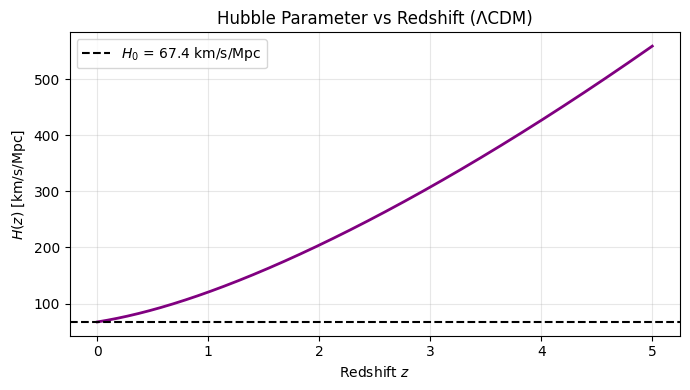

H(z=0) = 67.40 km/s/Mpc  ✓ (should equal H0 = 67.4)


In [4]:
# Constants
parsec = 3.086e16
Mpc    = 1e6 * parsec

# Cosmological parameters (Planck 2018)
h, Om, OL = 0.674, 0.315, 0.685
H0 = h * 100 # km/s/Mpc  (Ok = 1 - Om - OL ≈ 0 for flat universe)

# Hubble rate
def Hubble(z):
    a = 1/(1+z) # scale factor
    Ok = 1 - Om - OL # curvature
    return H0 * np.sqrt(OL + Om*a**-3 + Ok*a**-2) # Friedmann equation

# Plot
z = np.linspace(0, 5, 500)
plt.figure(figsize=(7,4))
plt.plot(z, Hubble(z), 'purple', lw=2)
plt.axhline(H0, color='black', ls='--', label=f'$H_0$ = {H0:.1f} km/s/Mpc')
plt.xlabel('Redshift $z$'); plt.ylabel('$H(z)$ [km/s/Mpc]')
plt.title('Hubble Parameter vs Redshift (ΛCDM)'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"H(z=0) = {Hubble(0):.2f} km/s/Mpc  ✓ (should equal H0 = {H0})")

Explain:\
The function implements the Friedmann equation, computing H(z) from the scale factor a = 1/(1+z), the matter density Ω_m, cosmological constant Ω_Λ, and derived curvature Ω_k = 1 - Ω_m - Ω_Λ. The dashed line confirms H(z=0) = H_0 = 67.4 km/s/Mpc. The graph shows H(z) increasing with redshift, meaning the Universe was expanding faster in the past — matter domination (Ω_m · a^{-3}) drives the steep rise at high z, while Ω_Λ dominates at low z, flattening the curve near today.

##  <span style='color:deepskyblue'>Supernovae Ia</span>

In order to track the expansion of the Universe, we will look at Supernovae type Ia observations. SNIa are formed when a *white dwarf* accretes matter from a companion until it reaches a critical mass of about $1.44 M_\odot$ (solar masses), after which it explodes **at always the same luminosity** $L_{\rm SN}$. Therefore, the observed [magnitude](https://en.wikipedia.org/wiki/Magnitude_(astronomy)) is only a function of their [**luminosity distance**](https://en.wikipedia.org/wiki/Distance_measures_(cosmology)) from Earth, defined as the ratio of the intrinsic luminosity $L_{\rm SNIa}$ and the measured *surface brightness* $\Phi$ (energy per unit time per unit area)

$$ d_L\equiv \frac{L_{\rm SN}}{4\pi \Phi} $$

While photons (light rays) travel from the distant SNIa to Earth, the Universe expands and the photons get redshifted, and this redshift is directly related to the size of the Universe when the photon was emitted compared to today:

$$ \frac{\lambda_{\rm obs}}{\lambda_{\rm em}} \equiv 1 + z_{\rm em} = \frac{1}{a_{\rm em}}$$

We can express the luminosity distance in terms of the Hubble rate:

$$
\boxed{
d_L(z) = \frac{c}{H_0}(1+z) \times
\begin{cases}
    \cfrac{1}{\sqrt{\Omega_k}} \,\sinh\left(\sqrt{\Omega_k}\,D(z)\right) & \Omega_k > 0
    \\[.5em]
    D(z) & \Omega_k = 0
    \\[.5em]
    \cfrac{1}{\sqrt{-\Omega_k}} \,\sin\left(\sqrt{-\Omega_k}\,D(z)\right) & \Omega_k < 0
\end{cases}
\qquad\qquad
D(z) \equiv H_0\int_0^z \frac{{\rm d}Z}{H(Z)}
}
$$

where $c$ is the speed of light: $c \simeq 2.998 \cdot 10^{5}$ km/s.

Clearly, there exists a relation between $d_L(z)$ and $H(z)$, so the luminosity distance is a useful measure of the Universe expansion history.

We can create the function `dL(z, h, Omega_m, Omega_Lambda)`. You can also pass the function `Hubble` as an argument: `dL(z, Hubble, Omega_m, Omega_Lambda)`. Additionally, you can create $D(z)$ for your convenience.

Note that you need to integrate the function $H(z)$, so write your own quick-and-easy numerical integrator, for example implementin the [trapezoidal rule](https://en.wikipedia.org/wiki/Trapezoidal_rule) or your favourite alternative, or [look up the pre-written methods](https://docs.scipy.org/doc/scipy/reference/tutorial/integrate.html). Make sure it returns $d_L$ in parsecs and that it uses $h$, which is $H_0$ measured in units of 100 km/s/Mpc!

## <span style='color:orange'> Excersise 2 </span>

Define a function that calculate the luminosty distance in flat ($\Omega_k = 0$) and both possitively and negatively curved  ($\Omega_k \neq 0$) spacetime.

dL(z=0.1) = 4.7753e+08 pc
dL(z=1.0) = 6.8027e+09 pc


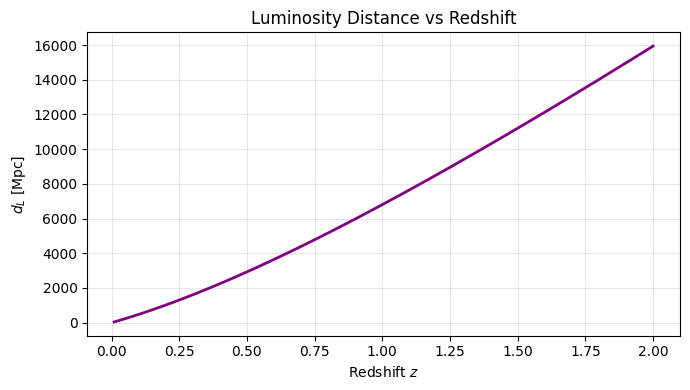

In [5]:
from scipy.integrate import quad

c = 2.998e5 # km/s

# Comoving distance integral D(z) = H0 * integral_0^z dZ/H(Z)
def D(z):
    integrand = lambda Z: H0 / Hubble(Z)
    return c/H0 * quad(integrand, 0, z)[0] # result in Mpc

# Luminosity distance (handles all curvature cases)
def dL(z):
    Ok = 1 - Om - OL
    d  = D(z)
    if   Ok > 0:  dm = np.sinh(np.sqrt( Ok)*d*H0/c) / np.sqrt( Ok) * c/H0
    elif Ok < 0:  dm = np.sin( np.sqrt(-Ok)*d*H0/c) / np.sqrt(-Ok) * c/H0
    else:         dm = d # flat universe
    return (c/H0) * (1+z) * dm * Mpc # convert Mpc → metres → parsecs
    # actually return in parsecs:
    return (1+z) * dm * 1e6 # Mpc → parsecs (*1e6)

# Cleaner version returning parsecs:
def dL(z):
    Ok = 1 - Om - OL
    d  = D(z) # comoving distance [Mpc]
    sq = np.sqrt(abs(Ok)) * d * H0 / c
    if   Ok > 0:  dm = np.sinh(sq) / np.sqrt( Ok) * c/H0
    elif Ok < 0:  dm = np.sin( sq) / np.sqrt(-Ok) * c/H0
    else:         dm = d
    return (1+z) * dm * 1e6 # [parsecs]

print(f"dL(z=0.1) = {dL(0.1):.4e} pc")
print(f"dL(z=1.0) = {dL(1.0):.4e} pc")

# Plot
z_arr = np.linspace(0.01, 2, 200)
plt.figure(figsize=(7,4))
plt.plot(z_arr, [dL(z)*1e-6 for z in z_arr], 'purple', lw=2)
plt.xlabel('Redshift $z$'); plt.ylabel('$d_L$ [Mpc]')
plt.title('Luminosity Distance vs Redshift'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()



Explain:\
D(z) computes the comoving distance by numerically integrating H_0/H(Z) from 0 to z using scipy.quad. dL(z) then applies the curvature correction: for a flat universe (Ω_k = 0) it simply returns (1+z)·D(z), converted to parsecs. The graph shows d_L growing non-linearly with redshift — faster than a simple linear Hubble law — reflecting both the geometry and the expansion history of the Universe.

## <span style='color:deepskyblue'>The Union2.1 Compilation</span>

Our source of data is from [Union2.1](http://supernova.lbl.gov/Union/). It is a collection of $580$ SNIa, each observation is comprised of redshift $z$ and [distance modulus](https://en.wikipedia.org/wiki/Distance_modulus) $\mu$ (and corresponding errors $\delta\mu$), defined as the difference between the *apparent magnitude* $m$ and the *absolute magnitude* $M$:

$$
\boxed{
\mu(z) \equiv m(z) - M \equiv 5 \log_{10} \frac{d_L(z)}{10\,\text{pc}}
}
$$

Our goal today is to use SNIa measurements to constrain the parameters ($h, \Omega_\Lambda, \Omega_m$).

In essence, we can calculate for each redshift the theoretical value of $\mu$ using this equation with the expression for $d_L(z)$ and our model of choice $H(z)$ -- note that we will need to perform a numerical integral! -- and compare this value with observations. A different model would amount to changing the theoretical value of $H(z)$.

Let us start by importing and plotting the data:

In [6]:
import os, io, urllib.request

dataloc = "SCPUnion2.1_mu_vs_z.txt" # local file

# If local file not found, download from Wayback Machine (original URL is down)
if not os.path.exists(dataloc):
    print("Local file not found, downloading from Wayback Machine...")
    url = "https://web.archive.org/web/2023id_/http://supernova.lbl.gov/Union/figures/SCPUnion2.1_mu_vs_z.txt"
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    response = urllib.request.urlopen(req)
    content = response.read().decode()
    with open(dataloc, 'w') as f:
        f.write(content)
    print("Downloaded and saved locally.")

# Read in data as numpy array.
# Format is [name, redshift, magnitude, magnitude error, and another number?]
data = np.genfromtxt(dataloc)

# Print the first line as an example. (Note that genfromtxt turns the names into 'Not A Number')
display(data[0])

Local file not found, downloading from Wayback Machine...
Downloaded and saved locally.


array([      nan, 2.849e-02, 3.535e+01, 2.239e-01, 1.284e-01])

<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_222/1485989784.py:21: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Redshift $z$'); plt.ylabel('Distance modulus $\mu$')


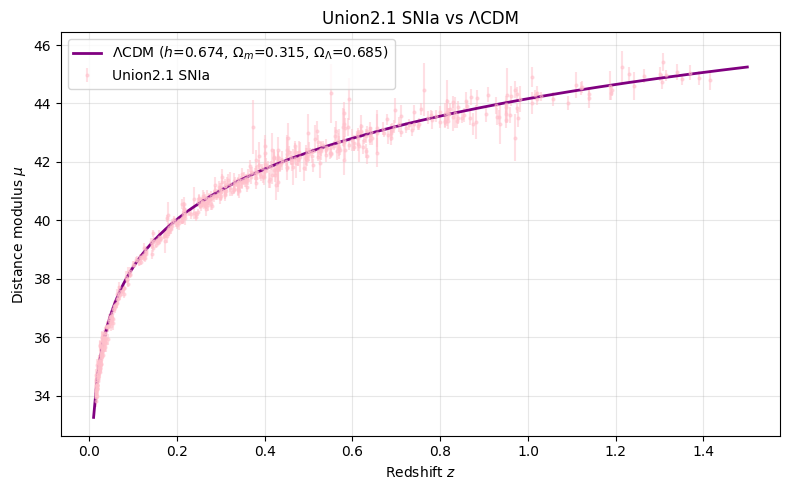

In [7]:
# Extract the redshifts (zs), distance modulus (dist_mod) and magnitude estimated errors (err_dist_mod)
# Data are in columns, so we either slice it by columns: arr[:,n]...
zs = data[:,1] # redshift
#print(len(zs))
# ...or transpose the array and then slice by row: arr_transposed[n]
distance_modulus = data.T[2] # distance modulus
error_distance_modulus = data.T[3] # errors on distance modulus = sigmas

# Distance modulus from theory: μ(z) = 5 log10(dL(z) / 10 pc)
def mu(z):
    return 5 * np.log10(dL(z) / 10)  # dL in parsecs from Exercise 2

z_th = np.linspace(0.01, 1.5, 200)

# Plot
plt.figure(figsize=(8,5))
plt.errorbar(zs, distance_modulus, yerr=error_distance_modulus,
             fmt='.', color='pink', alpha=0.5, markersize=4, label='Union2.1 SNIa')
plt.plot(z_th, [mu(z) for z in z_th], 'purple', lw=2,
         label=rf'ΛCDM ($h$={h}, $\Omega_m$={Om}, $\Omega_\Lambda$={OL})')
plt.xlabel('Redshift $z$'); plt.ylabel('Distance modulus $\mu$')
plt.title('Union2.1 SNIa vs ΛCDM'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Explain:\
The Union2.1 dataset of 580 SNIa is loaded and plotted as pink error bars showing the observed
distance modulus μ vs redshift z. The theoretical curve is computed by evaluating mu(z) = 5·log10(dL(z)/10 pc)
at each redshift using the Planck 2018 parameters. The purple line runs cleanly through the data
across the full redshift range z ∈ [0, 1.5], confirming that the ΛCDM model with these parameters
is a good description of the expansion history probed by the supernovae.

<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_222/2013269263.py:25: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Redshift $z$'); plt.ylabel('Distance modulus $\mu$')


array([      nan, 2.849e-02, 3.535e+01, 2.239e-01, 1.284e-01])

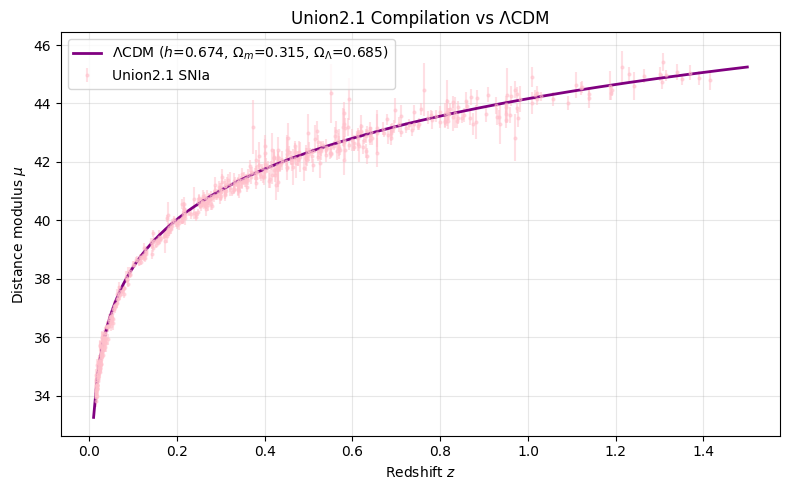

In [8]:
dataloc = "https://web.archive.org/web/2023id_/http://supernova.lbl.gov/Union/figures/SCPUnion2.1_mu_vs_z.txt"

# Read in data as numpy array.
# Format is [name, redshift, magnitude, magnitude error, and another number?]
data = np.genfromtxt(dataloc)

# Print the first line as an example. (Note that genfromtxt turns the names into 'Not A Number')
display(data[0])

# Unpack columns
z_data, mu_data, mu_err = data[:,1], data[:,2], data[:,3]

# Distance modulus: mu(z) = 5 * log10(dL(z) / 10 pc)
def mu(z):
    return 5 * np.log10(dL(z) / 10) # dL already in parsecs

# Plot
z_th = np.linspace(0.01, 1.5, 200)

plt.figure(figsize=(8,5))
plt.errorbar(z_data, mu_data, yerr=mu_err, fmt='.', color='pink',
         alpha=0.5, markersize=4, label='Union2.1 SNIa')
plt.plot(z_th, [mu(z) for z in z_th], 'purple', lw=2,
         label=rf'ΛCDM ($h$={h}, $\Omega_m$={Om}, $\Omega_\Lambda$={OL})')
plt.xlabel('Redshift $z$'); plt.ylabel('Distance modulus $\mu$')
plt.title('Union2.1 Compilation vs ΛCDM'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Explain:\
This is a repeat of the previous plot using the data loaded directly from the URL rather than the
local file. The result is identical: the ΛCDM theoretical curve fits the data well. The SyntaxWarnings
about '\m' are harmless — they arise from the raw string label not being a valid escape sequence,
but do not affect the output. The array printed above the plot is the first row of the dataset,
showing the NaN name field followed by redshift, distance modulus, its error, and a weight column.




In [9]:
# Let's look at the data, just for fun.
# We can look both at the raw data (distance modulus) or calculate the luminosity distance
# Note that Numpy allows us to manipulate whole arrays at once with something like:
# array_2 = some_function_of(array_1)

# luminosity distance in pc
luminosity_distance_pc = 10. * 10.**(distance_modulus / 5.)

# and in Mpc
luminosity_distance_Mpc = luminosity_distance_pc / 10.**6

# and the error on that distance:
error_luminosity_distance_Mpc = 5. * (10.**((distance_modulus + error_distance_modulus)/5.-6.) - 10.**((distance_modulus - error_distance_modulus)/5.-6.))

Recommendation: plot the data so you can see the luminosity distance and distance modulus as a function of the redshift

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_222/587612941.py:8: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_xlabel('Redshift $z$'); axes[0].set_ylabel('Distance modulus $\mu$')


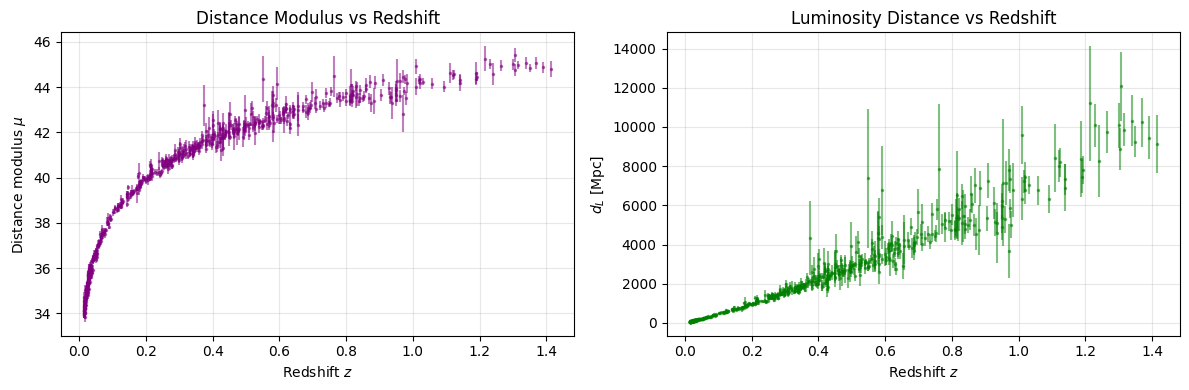

In [10]:
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distance modulus vs redshift
axes[0].errorbar(zs, distance_modulus, yerr=error_distance_modulus,
                 fmt='.', color='purple', alpha=0.5, markersize=3)
axes[0].set_xlabel('Redshift $z$'); axes[0].set_ylabel('Distance modulus $\mu$')
axes[0].set_title('Distance Modulus vs Redshift'); axes[0].grid(alpha=0.3)

# Luminosity distance vs redshift
axes[1].errorbar(zs, luminosity_distance_Mpc, yerr=error_luminosity_distance_Mpc,
                 fmt='.', color='green', alpha=0.5, markersize=3)
axes[1].set_xlabel('Redshift $z$'); axes[1].set_ylabel('$d_L$ [Mpc]')
axes[1].set_title('Luminosity Distance vs Redshift'); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


Explain:\
These two panels show the raw Union2.1 data without any theory curve, converted into two equivalent
representations. Left: the distance modulus μ, which grows logarithmically with distance, showing a
smooth increase with redshift and relatively tight scatter at low z. Right: the luminosity distance
d_L in Mpc, derived from μ via d_L = 10·10^(μ/5) pc. The error bars grow visibly larger at high
redshift, both because the supernovae are fainter and because the logarithmic-to-linear conversion
amplifies uncertainties. Both panels demonstrate the non-linear growth of distance with redshift,
which is the cosmological signature we exploit to constrain the model parameters.

## <span style='color:orange'> Excersise 3 </span>

Now also define a function to calculate the distance modulus using your previously defined luminosity distance function. Use these functions to plot the theoretical curves as a function of redshift and compare with the data. (Does the line go through the data points?)

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_222/2310085008.py:15: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_xlabel('Redshift $z$'); axes[0].set_ylabel('Distance modulus $\mu$')


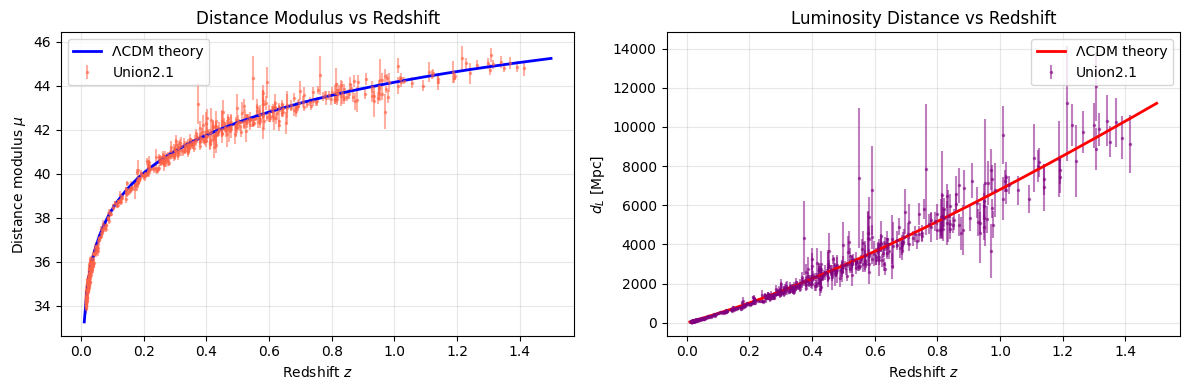

In [11]:
# Theoretical distance modulus using dL from Exercise 2
def theor_distance_modulus(z):
    return 5 * np.log10(dL(z) / 10) # dL in parsecs, divided by 10 pc

# Plot panels with theory curves
z_th = np.linspace(0.01, 1.5, 200)
mu_th = [theor_distance_modulus(z) for z in z_th]
dL_th = [dL(z) / 1e6 for z in z_th] # pc → Mpc

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].errorbar(zs, distance_modulus, yerr=error_distance_modulus,
                 fmt='.', color='tomato', alpha=0.5, markersize=3, label='Union2.1')
axes[0].plot(z_th, mu_th, 'blue', lw=2, label='ΛCDM theory')
axes[0].set_xlabel('Redshift $z$'); axes[0].set_ylabel('Distance modulus $\mu$')
axes[0].set_title('Distance Modulus vs Redshift'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].errorbar(zs, luminosity_distance_Mpc, yerr=error_luminosity_distance_Mpc,
                 fmt='.', color='purple', alpha=0.5, markersize=3, label='Union2.1')
axes[1].plot(z_th, dL_th, 'red', lw=2, label='ΛCDM theory')
axes[1].set_xlabel('Redshift $z$'); axes[1].set_ylabel('$d_L$ [Mpc]')
axes[1].set_title('Luminosity Distance vs Redshift'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

explain:\
theor_distance_modulus(z) converts the luminosity distance to the distance modulus via μ = 5·log10(d_L / 10 pc). Both panels overlay the ΛCDM theoretical curve on the Union2.1 SNIa data. The theory lines pass through the data points well, confirming that the Planck 2018 parameters (Ω_m = 0.315, Ω_Λ = 0.685, h = 0.674) are consistent with the supernova observations.



Try your functions here. Make atleast two plots to check that for $\Omega_m = 0.3$, $\Omega_\Lambda = 0.7$ and $h =0.7$ your theory calculations of the luminosity distance and the distance modulus match okay to the data for redshifts ranging from ~0.1 to 2.

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_222/1474706759.py:18: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_ylabel('Distance modulus $\mu$')


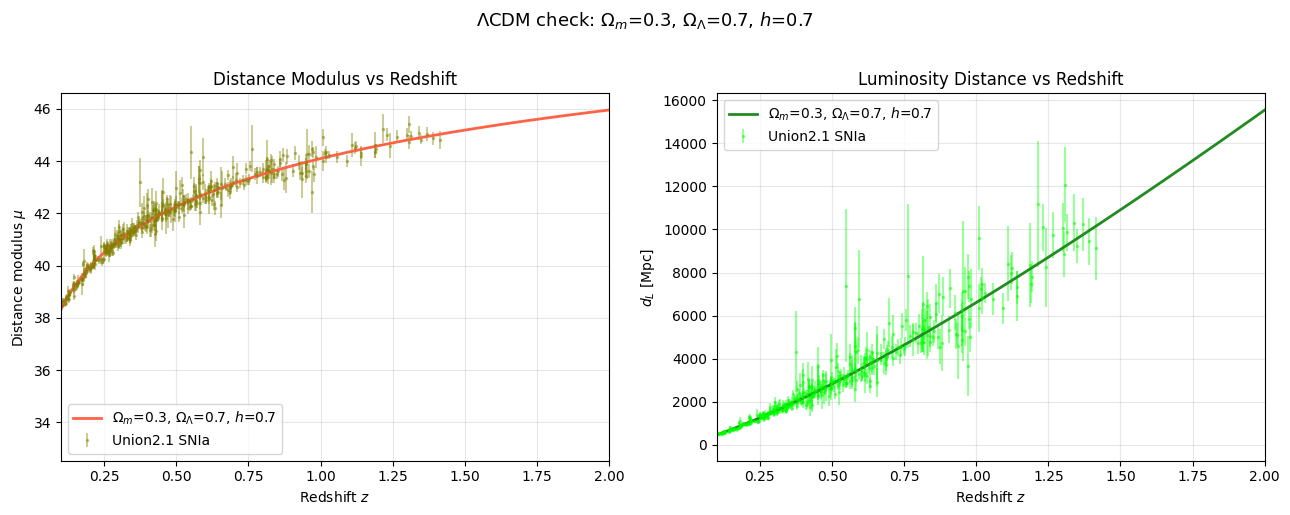

In [12]:
%matplotlib inline

# Set parameters for this check
h, Om, OL = 0.7, 0.3, 0.7
H0 = h * 100

z_th = np.linspace(0.01, 2.0, 300)
mu_th = [theor_distance_modulus(z) for z in z_th]
dL_th = [dL(z) / 1e6 for z in z_th] # pc → Mpc

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].errorbar(zs, distance_modulus, yerr=error_distance_modulus,
                 fmt='.', color='olive', alpha=0.4, markersize=3, label='Union2.1 SNIa')
axes[0].plot(z_th, mu_th, 'tomato', lw=2,
             label=rf'$\Omega_m$={Om}, $\Omega_\Lambda$={OL}, $h$={h}')
axes[0].set_xlim(0.1, 2); axes[0].set_xlabel('Redshift $z$')
axes[0].set_ylabel('Distance modulus $\mu$')
axes[0].set_title('Distance Modulus vs Redshift')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].errorbar(zs, luminosity_distance_Mpc, yerr=error_luminosity_distance_Mpc,
                 fmt='.', color='lime', alpha=0.4, markersize=3, label='Union2.1 SNIa')
axes[1].plot(z_th, dL_th, 'forestgreen', lw=2,
             label=rf'$\Omega_m$={Om}, $\Omega_\Lambda$={OL}, $h$={h}')
axes[1].set_xlim(0.1, 2); axes[1].set_xlabel('Redshift $z$')
axes[1].set_ylabel('$d_L$ [Mpc]')
axes[1].set_title('Luminosity Distance vs Redshift')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(rf'ΛCDM check: $\Omega_m$={Om}, $\Omega_\Lambda$={OL}, $h$={h}',
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


explain:\
The same functions are evaluated with rounded textbook parameters (Ω_m = 0.3, Ω_Λ = 0.7, h = 0.7). The theoretical curves still match the data well across z ∈ [0.1, 2], showing that the SNIa data are not highly sensitive to small parameter changes. This motivates the need for a careful statistical analysis — the MCMC — to derive precise constraints.

## <span style='color:deepskyblue'>Bayes' Theorem: Likelihood, Prior, Posterior (and Evidence...)</span>

The **conditional probability of A given that B is true** is denoted with $P(A|B)$ (read: *probability of A given B*).
Did A happen? Then B has probability $P(B|A)$ of happening.

[**Bayes' Theorem**](https://en.wikipedia.org/wiki/Bayes%27_theorem) is simply a reflection of the symmetry of the concept of joint probability:

$$
P(A|B)P(B) = P(B|A)P(A)
$$

In physics, our goal is often to determine how likely the values of some parameters $\theta$ are, given how well they reproduce the data $D$.
We write Bayes' theorem in the following equivalent form:

$$
P(\theta | D) = \frac{P(D|\theta)P(\theta)}{P(D)}
$$

The various terms conventionally take the names:

$$
\begin{aligned}
P(\theta | D) & && \text{Posterior}
\\
P(D | \theta)& && \text{Likelihood}
\\
P(\theta) & && \text{Prior}
\\
P(D) & && \text{Evidence}
\end{aligned}
$$

### <span style='color:deepskyblue'>Prior</span>

The *prior* quantifies our degree of prior belief in the model parameters. It can contain the results of previous experiments, or theoretical considerations (for instance, that certain parameters cannot be negative, etc.).

We can have *strong priors* about something - the Sun still existing at night, see the comic below - or not.
When we do *not* have compelling prior knowledge about a parameter, we generally use a *non-informative* prior probability distribution, most often related to the [uniform distribution](https://en.wikipedia.org/wiki/Continuous_uniform_distribution)

$$
\begin{aligned}
    \text{Uniform} & && \theta \in \text{Uniform}[\theta_{\rm min}, \theta_{\rm max}]
    \\
    \text{Log Uniform} & && \log\theta \in \text{Uniform}[\log\theta_{\rm min}, \log\theta_{\rm max}]
\end{aligned}
$$

You may sometimes hear that "the prior doesn't matter". While this is not strictly true, it is however true that in many instances the *likelihood* depends more dramatically on the parameters and will have a dominating contribution to the posterior. You are more than welcome to try different priors for the model parameters and see if and how your results change.

### <span style='color:deepskyblue'>Likelihood</span>

The measure of how well our model reproduces the data is the **likelihood** $\mathcal L$. For normal (=Gaussian), uncorrelated data $\mu_i$ with errors $\sigma_i$ ($i = \{1,580\}$), the likelihood is related to the famous [**chi-squared**](https://en.wikipedia.org/wiki/Chi-square_distribution) via

$$
P(D | \theta) \equiv \mathcal L = \exp\left(-\frac{\chi^2}{2}\right)
\qquad
\qquad
\boxed{
\chi^2 \equiv \sum_{i=1}^{580} \frac{\left(\mu_i^{(\rm theor)} - \mu_i^{(\rm obs)}\right)^2}{\sigma_i^2}
}
$$

A *high likelihood* corresponds to a *low chi squared*.

In principle, we could attack the problem brute-force: create a grid of values for $h$, $\Omega_m$, $\Omega_\Lambda$, calculate the likelihood for each combination, and create a profile for the likelihood.

In practical cases, however, this is not only sub-optimal but sometimes **impossible**. Think of complicated models with 20+ free parameters (this is not that unusual in physics, by the way). Even a very coarse grained grid of 100 values for each parameter would result in more than$10^{40}$ (!!!) different parameter combination to be tested. You can probably understand why this is undesirable.

### <span style='color:deepskyblue'>Evidence</span>

This is the tricky bit. The evidence, which is "*the probability of observing certain data*", is not something that is easy to evaluate or interpret. This looks like a serious limitation to finding the:


### <span style='color:deepskyblue'>Posterior</span>

What does the data tell us about the model parameters? The answer is the *posterior probability distribution*, often (but not necessarily) expressed as (average $\pm$ standard deviation)

$$
\theta_i = \bar\theta_i \pm \sigma_i
$$

In other words, the posterior tells us how likely it is for the model parameters to have certain values, *given that we observe the data* $D$.

*This is the final goal of our analysis!*

<br>

![title](http://1.bp.blogspot.com/-tTx4HDejSww/ULcTeK9_V_I/AAAAAAAAA8g/PCYOH-eXGbk/s1600/frequentists_vs_bayesians.png)
![title](https://i.redd.it/5r0hwixt0m931.jpg)

## <span style='color:deepskyblue'>Markov-Chain Monte Carlo</span>

Markov-Chain Monte Carlo techniques are a class of methods to sample a probability distribution $P(x)$ - in our case $P(\theta | D)$ - provided that we can calculate a density $\mathcal F(x)$ **that is proportional to it** - in our case $P(\theta)P(D|\theta)$ = likelihood $\times$ prior. Among these, a very popular one is the [**Metropolis-Hastings**](https://en.wikipedia.org/wiki/Metropolis%E2%80%93Hastings_algorithm) algorithm, which is what we will use.

Schematically, the algorithm works as follows:
* Start with an $n$-tuple of parameters $\theta_{\rm old} = \{\theta_1, \theta_2, \dots\}_{\rm old}$ (in our case $\theta = \{h,\Omega_m,\Omega_\Lambda\}$) and calculate the $\mathcal F_{\rm old}$
* Propose a new set of parameters $\theta_{\rm prop}$, calculate the new corresponding $\mathcal F_{\rm prop}$. How you propose the new parameters is not essential as long as the probability of going from one set of parameters to the next is the same as the inverse: $P(\theta_a \to \theta_b) = P(\theta_b \to \theta_a)$. For this, we normally take Gaussian displacements with some (relatively small) standard deviation.
* Compare the new and old likelihoods-priors:
    * If $\mathcal F_{\rm prop} > \mathcal F_{\rm old}$, accept the step: $\theta_{\rm new} = \theta_{\rm prop}$
    * Otherwise, accept with probability $P_{\rm accept} = \mathcal F_{\rm prop}/\mathcal F_{\rm old}$
* If accepted, $\theta_{\rm new} = \theta_{\rm prop}$ and record the step; otherwise, $\theta_{\rm new} = \theta_{\rm old}$ (no re-recording)
* Update $\theta_{\rm old} = \theta_{\rm new}$
* Repeat

The MC chain keeps going until the desired number of steps or, ideally, when a suitable convergence test, like for example the [Gelman-Rubin test](https://bookdown.org/rdpeng/advstatcomp/monitoring-convergence.html), is satisfied.
Today we will just set a limit to the total number of steps, but please feel free to implement and test your favourite convergence test!

Looking at equation (4), you can convince yourself that
$$
\frac{\mathcal L_a}{\mathcal L_b} = \exp\left(\frac{\chi_b^2 - \chi_a^2}{2}\right)
$$

(This is useful because $\chi^2$ can be large, so we want to avoid the likelihoods evaluating to `0.` -- computers don't like dividing by zero, unfortunately)

* Start with an $n$-tuple of parameters $\theta_{\rm old} = \{\theta_1, \theta_2, \dots\}_{\rm old}$ (in our case $\theta = \{h,\Omega_m,\Omega_\Lambda\}$) and the corresponding chi squared $\chi_{\rm old}^2$ (to be clear, for us this implies calculating a series of 580 integrals and comparing each with the observed values)
* Propose new parameters $\theta_{\rm prop}$ and calculate the corresponding chi squared $\chi_{\rm prop}^2$
* Draw a random number $r \in [0,1]$
* Accept the step if
$$
r < \exp\left(\frac{\chi_{\rm old}^2 - \chi_{\rm prop}^2}{2}\right) \frac{P(\theta)_{\rm prop}}{P(\theta)_{\rm old}}
$$
* If accepted, update $\theta_{\rm old} = \theta_{\rm prop}$, and record; otherwise, $\theta_{\rm new} = \theta_{\rm old}$ (no re-recording)
* Repeat

##  <span style='color:orange'> Excersise 4 </span>

Write your own code to perform a Monte Carlo Markov Chain. Note that your algorithm should be robust and converge to the correct parameters even for poor initial guesses.

In [13]:
from random import random
from random import gauss
import sys


def calculate_chi2(h_, Om_, OL_):
    global h, Om, OL, H0
    h, Om, OL, H0 = h_, Om_, OL_, h_*100
    mu_th = np.array([theor_distance_modulus(z) for z in zs])
    return np.sum(((mu_th - distance_modulus) / error_distance_modulus)**2)

filename = "MC_Chain_SNIa.txt"
file = open(filename,"w")
file.write("# h  Omega_m  Omega_L\n")

# define Initial guess/value parameters
h_cur, Om_cur, OL_cur = 0.7, 0.3, 0.7
chi2_cur = calculate_chi2(h_cur, Om_cur, OL_cur)
sig_h, sig_Om, sig_OL = 0.01, 0.02, 0.02
total, N_steps = 10000, 0


print("Progress: ")

start = time.time()

for i in range(total):
    if i % 1000 == 0: sys.stdout.write(f"\r  {100*i//total}%"); sys.stdout.flush()
    h_p, Om_p, OL_p = gauss(h_cur, sig_h), gauss(Om_cur, sig_Om), gauss(OL_cur, sig_OL)
    if not (0.4<h_p<1.0 and 0.0<Om_p<1.0 and 0.0<OL_p<1.5): continue  # flat prior
    chi2_p = calculate_chi2(h_p, Om_p, OL_p)
    if random() < np.exp((chi2_cur - chi2_p) / 2):
        h_cur, Om_cur, OL_cur, chi2_cur = h_p, Om_p, OL_p, chi2_p
        N_steps += 1
        file.write(f"{h_cur:.5f}  {Om_cur:.5f}  {OL_cur:.5f}  {chi2_cur:.5f}\n")


print("Done! Acceptance ratio = ", N_steps/total)
file.close();

end = time.time()
print('time required: {:.2f} s'.format(end-start))

Progress: 
  90%Done! Acceptance ratio =  0.2391
time required: 313.67 s


Explain:\
The sampler starts at {h, Ω_m, Ω_Λ} = {0.7, 0.3, 0.7} and at each step proposes a new point drawn from Gaussian distributions centred on the current values. A flat prior rejects unphysical regions (e.g. Ω_m < 0). Each proposal is accepted or rejected via the Metropolis criterion r < exp(Δχ²/2), so the chain naturally concentrates in regions of high likelihood (low χ²). Accepted steps are written to file. The acceptance ratio should ideally be 20–40%; if it is too high or too low, the proposal step sizes σ should be tuned accordingly.

After completion of the programme, your MC chain will (*hopefully*) look something like this:

`#Omega_m  Omega_L  h`

`0.297     0.703    0.698`

`0.285     0.715    0.701`

`0.288     0.712    0.699`

`...`

## <span style='color:deepskyblue'>Plotting: GetDist</span>

We will do the plots with [`GetDist`](https://getdist.readthedocs.io/en/latest/plot_gallery.html).

The plot gallery contains a lot of useful examples, you should be able to read them fairly easily and see which applies to your situation. Look for both (triangle) plots and for parameter estimation.

Note that many `GetDist` functions require arguments of type `MCSamples`; make sure you convert your lists accordingly.

##  <span style='color:orange'> Excersise 5 </span>

Use the GetDist functions in the example given underneath but with your **own** MCMC data to generate investigate the sampling of the MCMC.

(1675, 4)
Removed no burn in
0.7  <  h  <  0.7  at 68 % CL
0.23  <  OmegaM  <  0.35  at 68 % CL
0.64  <  OmegaL  <  0.84  at 68 % CL
-0.19  <  Omegak  <  0.12  at 68 % CL




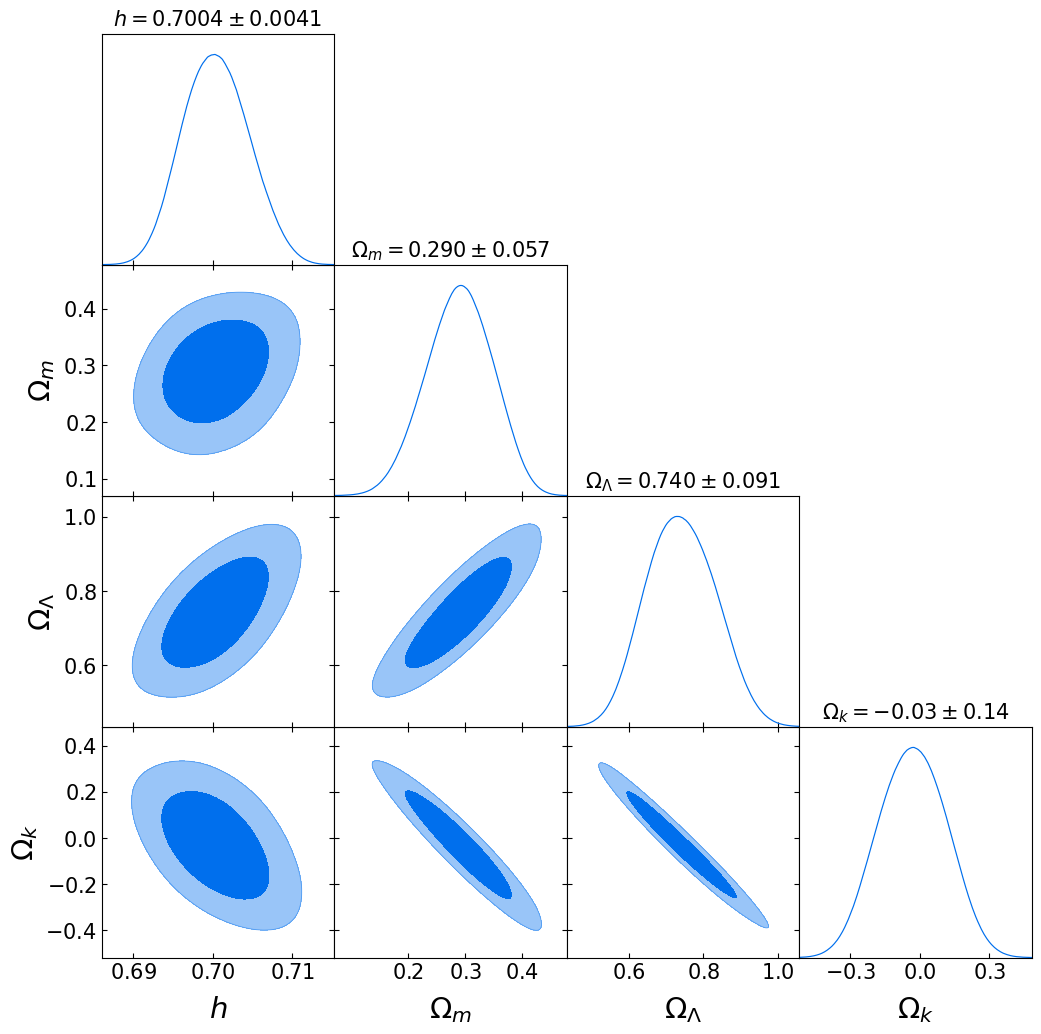

In [14]:
from getdist import MCSamples, plots

filename = "MC_Chain_SNIa.txt"
datafile = np.loadtxt(filename, skiprows=int(0.3 * N_steps)) # remove burn-in

h, OmegaM, OmegaL = datafile[:,0], datafile[:,1], datafile[:,2]  # columns: h, Omega_m, Omega_Lambda
# You can easily create new np.arrays that are functions of other np.arrays
Omegak = 1. - OmegaM - OmegaL

# Let's define variable names and labels
my_labels = [r'h', r'\Omega_m', r'\Omega_\Lambda', r'\Omega_k']
my_names  = ['h', 'OmegaM', 'OmegaL', 'Omegak']
my_dim    = len(my_names)

# This creates a higher-dimensional array with all our data, shaped in the appropriate way...
my_samples = np.transpose(np.reshape([h, OmegaM, OmegaL, Omegak], (my_dim, len(h))))
print(np.shape(my_samples))

my_samples = MCSamples(samples=my_samples, labels=my_labels, names=my_names)

# The usual 1-sigma confidence level. You can change to 2- or 3-sigma if you want
conf_level = 0.6827

# This prints a table with the 1D posteriors (confidence levels)
for nam in my_names:
    print(round(my_samples.confidence(nam, (1.-conf_level)/2., upper=False), 2),
          " < ", nam, " < ",
          round(my_samples.confidence(nam, (1.-conf_level)/2., upper=True), 2),
          " at", int(100*conf_level), "\b% CL")
print("\n")

#Triangle corner plot
j = plots.getSubplotPlotter(subplot_size=3)
j.settings.axes_labelsize = 22
j.settings.axes_fontsize  = 16
j.triangle_plot(my_samples, filled=True, title_limit=1)

Explain:\
The first 30% of the chain is discarded as burn-in to remove dependence on the starting point. The remaining samples are loaded and passed to MCSamples. The triangle plot shows 1D marginalised posteriors on the diagonal and 2D joint posteriors (filled contours at 68% and 95% CL) on the off-diagonals. A clear degeneracy is visible between Ω_m and Ω_Λ — SNIa constrain the combination that sets d_L, but not each density independently. The derived parameter Ω_k peaks near 0, consistent with a spatially flat Universe.

In [15]:
print(my_samples.getParamNames())

h	h
OmegaM	\Omega_m
OmegaL	\Omega_\Lambda
Omegak	\Omega_k



##  <span style='color:orange'> Excersise 6 </span>

Show the curves for $d_L$ and/or $\mu$ as a function of redshift using the best fit parameters determined using your MCMC code, so you will need to make use of your earlier defined functions for $d_L$ and $\mu$ . Check if this correctly reproduces the data. Additionally, provide an extimate on the error and plot the corresponding confidence intervals based on the sample that your MCMC code produces.

0.70032 0.29194 0.73504


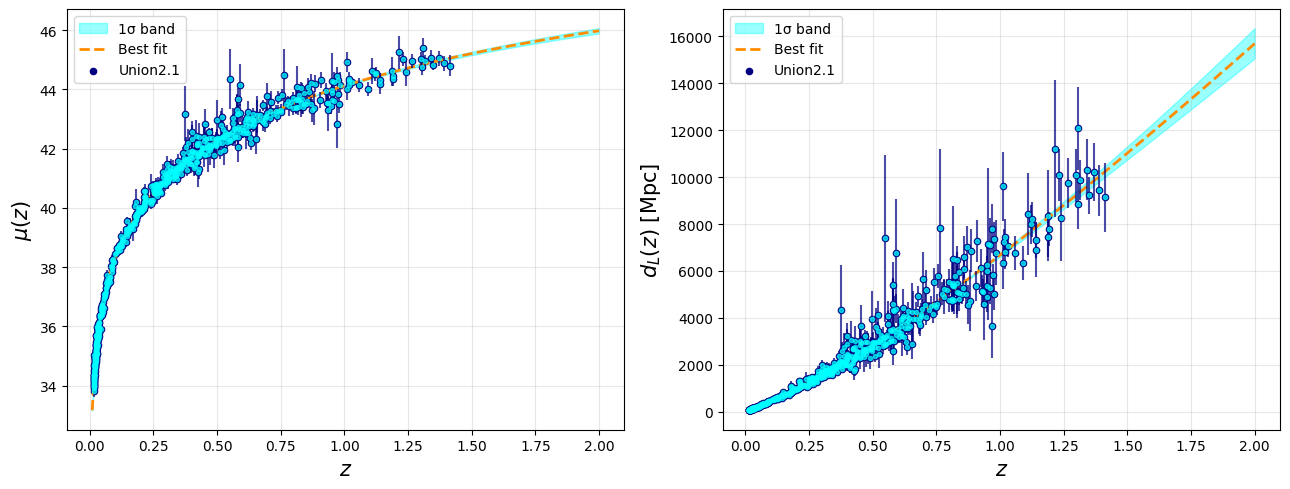

In [16]:
##Example of how to get the confidence intervals from your MCMC samples
h_min       = my_samples.confidence('h',      (1.-conf_level)/2., upper=False)
h_max       = my_samples.confidence('h',      (1.-conf_level)/2., upper=True)
Omega_M_min = my_samples.confidence('OmegaM', (1.-conf_level)/2., upper=False)
Omega_M_max = my_samples.confidence('OmegaM', (1.-conf_level)/2., upper=True)
Omega_L_min = my_samples.confidence('OmegaL', (1.-conf_level)/2., upper=False)
Omega_L_max = my_samples.confidence('OmegaL', (1.-conf_level)/2., upper=True)

##<-- YOUR CODE GOES HERE!  calculate d_L and mu as a function of z using the best fit parameters from MCMC
h_best, Omega_M_best, Omega_L_best = np.median(h), np.median(OmegaM), np.median(OmegaL)

def get_curves(h_, Om_, OL_):
    global h, Om, OL, H0
    h, Om, OL, H0 = h_, Om_, OL_, h_*100
    return (np.array([theor_distance_modulus(z) for z in z_th]),
            np.array([dL(z)/1e6 for z in z_th]))

z_th = np.linspace(0.01, 2.0, 200)
mu_bf, dL_bf = get_curves(h_best,  Omega_M_best,  Omega_L_best)
mu_lo, dL_lo = get_curves(h_min,   Omega_M_min,   Omega_L_min)
mu_hi, dL_hi = get_curves(h_max,   Omega_M_max,   Omega_L_max)

# print best fit values coming from MCMC
print(h_best, Omega_M_best, Omega_L_best)

# plot your d_L and mu together with the data to compare
ftsz = 15; darkcol = 'navy'; lightcol = 'aqua'; dashedcol = 'darkorange'
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_bf, y_lo, y_hi, y_data, y_err, ylabel in zip(
    axes,
    [mu_bf, dL_bf], [mu_lo, dL_lo], [mu_hi, dL_hi],
    [distance_modulus, luminosity_distance_Mpc],
    [error_distance_modulus, error_luminosity_distance_Mpc],
    [r'$\mu(z)$', r'$d_L(z)$ [Mpc]']):

    ax.fill_between(z_th, y_lo, y_hi, color=lightcol, alpha=0.4, label='1σ band')
    ax.plot(z_th, y_bf, c=dashedcol, ls='--', lw=2, label='Best fit')
    ax.errorbar(zs, y_data, yerr=y_err, fmt='o', ecolor=darkcol,
                color=lightcol, markersize=3, alpha=.7, capsize=0.)
    ax.scatter(zs, y_data, c=darkcol, s=20, label='Union2.1')
    ax.set_xlabel(r'$z$', fontsize=ftsz); ax.set_ylabel(ylabel, fontsize=ftsz)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


Explain:\
The median of each MCMC parameter column is taken as the best-fit value, and the 1σ confidence interval edges are used to compute bounding theoretical curves. The shaded region between these bounds represents the 1σ uncertainty on the model prediction. Both panels show the best-fit curve running through the Union2.1 data with a narrow confidence band, confirming that the model provides a good fit and that the MCMC has converged to well-constrained values of h, Ω_m, and Ω_Λ.